(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)
(5000,)


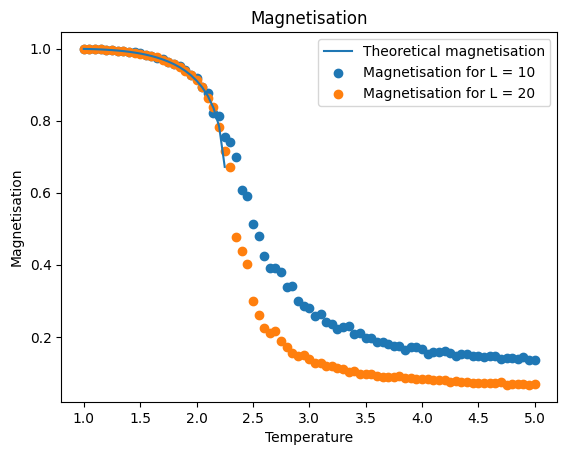

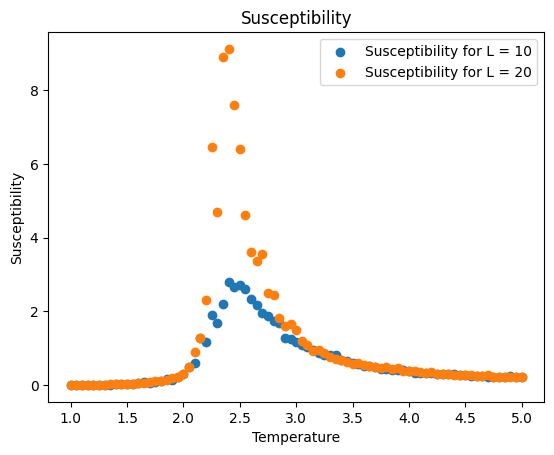

In [13]:
from numba import jit
from matplotlib import pyplot as plt
import numpy as np

N0 = 1000
N = 5000
Ls = [10, 20]
J = 1.
Ts = np.arange(1, 5 + 0.001, 0.05)
ts = np.arange(1, 2.27 + 0.001, 0.05)

@jit(nopython = True)
def vonNeumanNeighborhood(x, y, L_val):
    neighborurs = []
    neighborurs.append([(x + 1) % L_val, y])
    neighborurs.append([(x - 1) % L_val, y])
    neighborurs.append([x, (y + 1) % L_val])
    neighborurs.append([x, (y - 1) % L_val])
    return np.array(neighborurs)


@jit(nopython = True)
def mcs(T, L_val, current_lattice):
    for _ in range(L_val**2):
        i = np.array([np.random.randint(L_val), np.random.randint(L_val)])

        neighbours = vonNeumanNeighborhood(i[0], i[1], L_val)
        spinSum = 0.
        for neighbour in neighbours:
            spinSum += current_lattice[neighbour[0], neighbour[1]]
        energy_difference = 2 * J * spinSum
        r = np.random.uniform(0, 1)
        beta = 1. / T

        p = 1. / ( 1. + np.exp( (-1.) * beta * energy_difference ) )
        current_lattice[i[0], i[1]] = 1 if r < p else -1


magnetisationTable = dict()
magnetisationTableTheory = dict()
susceptibilityTable = dict()
t_c = 2.27

for L in Ls:
    avr_mag_T = []

    sus_T = []
    for T in Ts:
        sim_lattice = np.ones((L, L))
        ms = np.array([])
        magnetisationForTemperature = np.array([])
        beta = 1. / T
        for _ in range(N0):
            mcs(T, L, sim_lattice)
        for _ in range(N):
            mcs(T, L, sim_lattice)
            m = np.absolute( np.mean(sim_lattice) )
            ms = np.append(ms, m)

            magnetisation = np.abs( np.mean(sim_lattice) )

            magnetisationForTemperature = np.append(magnetisationForTemperature, magnetisation)
        print(magnetisationForTemperature.shape)
        averageMagnetisation = np.mean(magnetisationForTemperature)
        susceptibility = np.var(magnetisationForTemperature) * beta * L**2
        avr_mag_T.append([T, averageMagnetisation])
        sus_T.append([T, susceptibility])

        mag_average = np.mean(ms)
    magnetisationTable.update({L: np.array(avr_mag_T)})

    susceptibilityTable.update({L: np.array(sus_T)})

avr_mag_T_theory = []
for t in ts:

    if t < t_c:
        theory = (1 - (1. / (np.sinh(2*J/t)** 4))) **(1./8)
        avr_mag_T_theory.append([t, theory])

avr_mag_T_theory = np.array(avr_mag_T_theory)

plt.plot(avr_mag_T_theory[:,0], avr_mag_T_theory[:,1], label="Theoretical magnetisation")

for L in Ls:
    plt.scatter(magnetisationTable.get(L)[:,0], magnetisationTable.get(L)[:,1], label="Magnetisation for L = {}".format(L))

    plt.title(f"Magnetisation")
    plt.xlabel("Temperature")
    plt.ylabel("Magnetisation")
    plt.legend()
    plt.savefig(f"Magnetisation.png")

plt.show()

for L in Ls:
    plt.scatter(susceptibilityTable.get(L)[:,0], susceptibilityTable.get(L)[:,1], label="Susceptibility for L = {}".format(L))
    plt.title(f"Susceptibility")
    plt.xlabel("Temperature")
    plt.ylabel("Susceptibility")
    plt.legend()
    plt.savefig(f"Susceptibility.png")

plt.show()

In [ ]:

from matplotlib import pyplot as plt
import numpy as np

N0 = 100
N = 5000
Ls = [10, 20]
J = 1.
Ts = [1., 2., 3., 4., 5.]  # 1/ betha
ts = np.arange(1, 2.27 + 0.001, 0.05)

def vonNeumanNeighborhood(x, y):
    neighborurs = []
    neighborurs.append([(x + 1) % L, y])
    neighborurs.append([(x - 1) % L, y])
    neighborurs.append([x, (y + 1) % L])
    neighborurs.append([x, (y - 1) % L])
    return np.array(neighborurs)


lattice = np.ones((1, 1))

def mcs(T):
    i = np.array([np.random.randint(L), np.random.randint(L)])

    neighbours = vonNeumanNeighborhood(i[0], i[1])
    spinSum = 0.
    for neighbour in neighbours:
        spinSum += lattice[neighbour[0], neighbour[1]]
    energy_difference = 2 * J * spinSum
    r = np.random.uniform(0, 1)
    beta = 1. / T

    p = 1. / ( 1. + np.exp( (-1.) * beta * energy_difference ) )
    lattice[i[0], i[1]] = 1 if r < p else -1


magnetisationTable = dict()
magnetisationTableTheory = dict()
susceptibilityTable = dict()
t_c = 2.27

for L in Ls:
    lattice = np.ones((L, L))
    avr_mag_T = []

    sus_T = []
    for T in Ts:
        lattice = np.ones((L, L))
        ms = np.array([])
        magnetisationForTemperature = np.array([])
        beta = 1. / T
        for _ in range(N0):
            mcs(T)
        for _ in range(N):
            mcs(T)
            m = np.absolute( np.mean(lattice) )
            ms = np.append(ms, m)
            magnetisation = np.mean(lattice) # magnetisation table
            magnetisationForTemperature = np.append(magnetisationForTemperature, magnetisation)
        averageMagnetisation = np.mean(np.abs(magnetisationForTemperature))
        susceptibility = np.var(magnetisationForTemperature) * beta * L**2
        # np.var(MagnetizationTable) * beta * L**2
        avr_mag_T.append([T, averageMagnetisation])
        sus_T.append([T, susceptibility])

        mag_average = np.mean(ms)
        #print(f"T = {T}, mag_average = {mag_average}")
    magnetisationTable.update({L: np.array(avr_mag_T)})

    susceptibilityTable.update({L: np.array(sus_T)})

avr_mag_T_theory = []
for t in ts:

    if t < t_c:
        theory = (1 - (1. / (np.sinh(2*J/t)** 4))) **(1./8)
        avr_mag_T_theory.append([t, theory])

avr_mag_T_theory = np.array(avr_mag_T_theory)

#print(magnetisationTable.get(10))
plt.plot(avr_mag_T_theory[:,0], avr_mag_T_theory[:,1], label="Theoretical magnetisation")

for L in Ls:
    plt.plot(magnetisationTable.get(L)[:,0], magnetisationTable.get(L)[:,1], label="Magnetisation for L = {}".format(L))

    plt.title(f"Magnetisation")
    plt.xlabel("Temperature")
    plt.ylabel("Magnetisation")
    plt.legend()
    plt.savefig(f"Magnetisation.png")

plt.show()

for L in Ls:
    plt.plot(susceptibilityTable.get(L)[:,0], susceptibilityTable.get(L)[:,1], label="Susceptibility for L = {}".format(L))
    plt.title(f"Susceptibility")
    plt.xlabel("Temperature")
    plt.ylabel("Susceptibility")
    plt.legend()
    plt.savefig(f"Susceptibility.png")

plt.show()

